Importação de Bibliotecas

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

Atribuição de Dataframe

In [16]:
df_logs = pd.read_csv('logs_exp_us.csv', sep='\\t', dtype={'EventName': 'category', 'ExpId': 'category'})
df_logs['EventTimestamp'] = pd.to_datetime(df_logs['EventTimestamp'], unit='s')
df_logs = df_logs.rename(columns={'EventName': 'event', 'DeviceIDHash': 'user_id', 'EventTimestamp': 'timestamp', 'ExpId': 'exp_id'})

C:\Users\GAMER\AppData\Local\Temp\ipykernel_11272\1516145421.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df_logs = pd.read_csv('logs_exp_us.csv', sep='\\t', dtype={'EventName': 'category', 'ExpId': 'category'})


Pré Análise de Dados

In [17]:
print(df_logs.info())
print(df_logs.describe())
print(df_logs.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   event      244126 non-null  category      
 1   user_id    244126 non-null  int64         
 2   timestamp  244126 non-null  datetime64[ns]
 3   exp_id     244126 non-null  category      
dtypes: category(2), datetime64[ns](1), int64(1)
memory usage: 4.2 MB
None
            user_id                      timestamp
count  2.441260e+05                         244126
mean   4.627568e+18  2019-08-04 10:18:35.842716160
min    6.888747e+15            2019-07-25 04:43:36
25%    2.372212e+18  2019-08-02 14:36:20.249999872
50%    4.623192e+18            2019-08-04 11:49:55
75%    6.932517e+18            2019-08-06 06:55:11
max    9.222603e+18            2019-08-07 21:15:17
std    2.642425e+18                            NaN
                     event              user_id           timestamp 

In [18]:
print(df_logs['exp_id'].unique())
print(df_logs['user_id'].nunique())

['246', '248', '247']
Categories (3, object): ['246', '247', '248']
7551


Adicione uma coluna de data e hora e uma coluna separada para datas

In [19]:
df_logs['hour'] = df_logs['timestamp'].dt.time
df_logs['date'] = df_logs['timestamp'].dt.date
df_logs['date'] = pd.to_datetime(df_logs['date'])
print(df_logs.sample(10))


                          event              user_id           timestamp  \
126059         MainScreenAppear  4696579772369540432 2019-08-04 13:30:55   
197799  PaymentScreenSuccessful  2656704080941585379 2019-08-06 14:16:57   
27664          MainScreenAppear  1968327796343926941 2019-08-01 15:57:18   
181060         CartScreenAppear  1754140665440434215 2019-08-06 05:45:28   
131285  PaymentScreenSuccessful  7983179173107104735 2019-08-04 15:55:33   
56043        OffersScreenAppear  6913623206643506129 2019-08-02 12:19:03   
192470         MainScreenAppear  9160437016685643194 2019-08-06 11:51:37   
97741        OffersScreenAppear   832195127918352542 2019-08-03 15:24:45   
154353         MainScreenAppear  5122452238037348165 2019-08-05 11:17:04   
100960  PaymentScreenSuccessful  2910761286178294850 2019-08-03 16:54:24   

       exp_id      hour       date  
126059    246  13:30:55 2019-08-04  
197799    246  14:16:57 2019-08-06  
27664     248  15:57:18 2019-08-01  
181060    247  

In [20]:
print(df_logs.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   event      244126 non-null  category      
 1   user_id    244126 non-null  int64         
 2   timestamp  244126 non-null  datetime64[ns]
 3   exp_id     244126 non-null  category      
 4   hour       244126 non-null  object        
 5   date       244126 non-null  datetime64[ns]
dtypes: category(2), datetime64[ns](2), int64(1), object(1)
memory usage: 7.9+ MB
None


Quantos eventos ficam nos registros?

In [21]:
df_logs['event'].unique()

['MainScreenAppear', 'PaymentScreenSuccessful', 'CartScreenAppear', 'OffersScreenAppear', 'Tutorial']
Categories (5, object): ['CartScreenAppear', 'MainScreenAppear', 'OffersScreenAppear', 'PaymentScreenSuccessful', 'Tutorial']

Quantos usuários ficam nos registros?

In [22]:
df_logs['user_id'].nunique()

7551

Qual é o número médio de eventos por usuário?

In [23]:
event_mean_per_user = len(df_logs) / df_logs['user_id'].nunique()
event_mean_per_user

32.33028737915508

Qual é o período de tempo que os dados cobrem? Encontre as datas máxima e mínima. Desenhe um histograma por data e hora. Você pode ter certeza de que possui os dados igualmente completos para todo o período? Os eventos mais antigos podem acabar aparecendo nos diários de alguns usuários por motivos técnicos, e isso pode distorcer o quadro geral. Encontre o momento em que os dados começam a ser completos e ignore a seção anterior. Qual período os dados realmente representam?

In [24]:
print(df_logs['date'].max())
print(df_logs['date'].min())

2019-08-07 00:00:00
2019-07-25 00:00:00


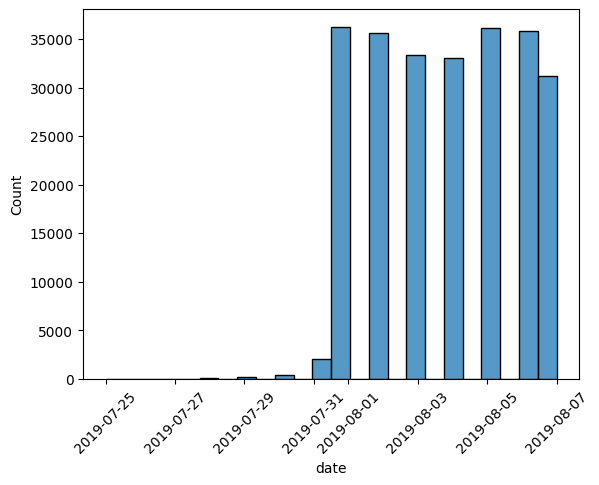

In [25]:
sns.histplot(df_logs['date'], bins=24)
plt.xticks(rotation=45)
plt.show()

Os eventos começam a ser relevantes somente a partir do dia 2019-08-01

In [26]:
df_logs_filter = df_logs[df_logs['date'] > '2019-07-31']
df_logs_filter = df_logs_filter.reset_index(drop=True)
df_logs_filter.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241298 entries, 0 to 241297
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   event      241298 non-null  category      
 1   user_id    241298 non-null  int64         
 2   timestamp  241298 non-null  datetime64[ns]
 3   exp_id     241298 non-null  category      
 4   hour       241298 non-null  object        
 5   date       241298 non-null  datetime64[ns]
dtypes: category(2), datetime64[ns](2), int64(1), object(1)
memory usage: 7.8+ MB


Você perdeu muitos eventos e usuários ao excluir os dados mais antigos?

In [28]:
user_lost = df_logs['user_id'].nunique() - df_logs_filter['user_id'].nunique()
print(f'Foram perdidos {user_lost} usuários.')

event_lost = len(df_logs['event']) - len(df_logs_filter['event'])
print(f'Foram perdidos {event_lost} eventos.')

Foram perdidos 17 usuários.
Foram perdidos 2828 eventos.


Certifique-se de ter usuários de todos os três grupos experimentais.

In [31]:
print(df_logs_filter['exp_id'].unique())
print(df_logs_filter['exp_id'].value_counts())

['246', '247', '248']
Categories (3, object): ['246', '247', '248']
exp_id
248    84726
246    79425
247    77147
Name: count, dtype: int64


Veja quais eventos estão nos diários e sua frequência de ocorrência. Classifique-os por frequência.

In [33]:
print(df_logs_filter['event'].value_counts().sort_values(ascending=False))

event
MainScreenAppear           117431
OffersScreenAppear          46350
CartScreenAppear            42365
PaymentScreenSuccessful     34113
Tutorial                     1039
Name: count, dtype: int64


Encontre o número de usuários que executaram cada uma dessas ações. Ordene os eventos pelo número de usuários. Calcule a proporção de usuários que executaram a ação pelo menos uma vez.